# Local Differential Privacy

## Central model

 - Trusted curator who holds the data set and executes the queries.
 - Potentially malicious analyst who asks the queries.

## Real worlds scenario

 - Clients with sensitive data
 - Organizations who collects and analyze the data
 - Clients want to protect data from the organizaions.
 - Example: cookies on webpages, Google, Apple, Microsoft, etc. collects data

## Local model

 - Parties: clients and a server
 - Clients: hold the sensitive data
 - Server: potentially malicious, collects and analyzes the data

How to achieve privacy in the local model?

## Local DP

 - Apply the DP mechanism to the data before sending it to the server.

Problems:
 - The noises are adding up.
 - The result is not accurate.

Only specific queries can be computed using local DP.

# Randomized response

## Motivation

 Ask sensitive questions in a survey.
 - Have you ever committed tax evasion?
 - Have you ever driven drunk?
 - Have you ever cheated on an exam?
 - What is your sexual orientation, religion, monthly income, etc?

Problem: Fear of social judgment, people do not answer honestly:

 - Van der Heijden et al. (https://journals.sagepub.com/doi/10.1177/0049124100028004005) face-to-face interview: 75 percent of respondents who committed welfare or unemployment benefits fraud denied doing so.
- Socially desirable attributes are over-reported, while socially undesirable attributes are under-reported when direct interrogation methods collect data.

 - Goals:
   - Deniability: No one can prove from the response that the respondent possesses the sensitive attribute.
   - Usable: The survey conductor can determine the approximate number of people with the sensitive attribute.

How to achieve the goals?

Idea: Lie with the answer with some probability!

## Warner's version (1965)

 - Idea: two questions/statements, which complement each other
      - *I have consumed marijuana.*
      - *I have never consumed marijuana.*
 - The respondent answers a randomly chosen one of the two.

## Algorithm

> 1. The interviewer asks two questions (A is true or A is not true).
>   - I have consumed marijuana.
>   - I have never consumed marijuana.
> 2. The respondent generates a random bit $b$ using a random source. With probability $p$ ($p̸ \neq0.5$) it outputs 0, and with probability
$1 − p$ it outputs 1. 
> 3. If b = 0, the respondent responds to the first question. Otherwise, it responds to the second question.

In [1]:
%load_ext jupyter_tikz

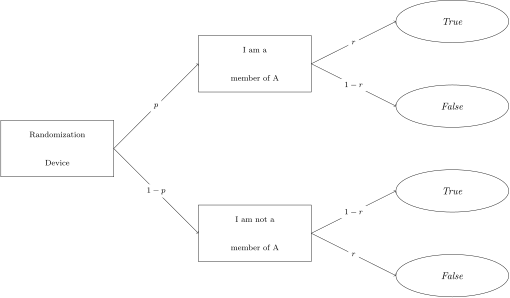

In [2]:
%%tikz -as=full-document
\documentclass[tikz]{standalone}
\begin{document}
        \begin{tikzpicture}[scale = 1]
        \draw (0,-1) rectangle (4,1);
        \draw[->] (4,0) -- (7,3);
        \draw[->] (4,0) -- (7,-3);
        \draw (7,2) rectangle (11,4);
        \draw (7,-2) rectangle (11,-4);
        \draw[->] (11,3) -- (14,4.5);
        \draw[->] (11,3) -- (14,1.5);
        \draw[->] (11,-3) -- (14,-4.5);
        \draw[->] (11,-3) -- (14,-1.5);
        \draw (16, 4.5) ellipse (2cm and 0.75cm);
        \draw (16, 1.5) ellipse (2cm and 0.75cm);
        \draw (16, -1.5) ellipse (2cm and 0.75cm);
        \draw (16, -4.5) ellipse (2cm and 0.75cm);
        

        \node at (2,0.5) {\footnotesize Randomization};
        \node at (2,-0.5) {\footnotesize Device};
        \node[fill=white] at (5.5,1.5) {\footnotesize $p$};
        \node[fill=white] at (5.5,-1.5) {\footnotesize $1-p$};
        \node at (9,3.5) {\footnotesize I am a };
        \node at (9,2.5) {\footnotesize member of A};
        \node at (9,-2.5) {\footnotesize I am not a};
        \node at (9,-3.5) {\footnotesize member of A};
        \node[fill=white] at (12.5,3.75) {\footnotesize $r$};
        \node[fill=white] at (12.5,2.25) {\footnotesize $1-r$};
        \node[fill=white] at (12.5,-3.75) {\footnotesize $r$};
        \node[fill=white] at (12.5,-2.25) {\footnotesize $1-r$};
        \node at (16,4.5) {\textit{True}};
        \node at (16,1.5) {\textit{False}};
        \node at (16,-1.5) {\textit{True}};
        \node at (16,-4.5) {\textit{False}};
    \end{tikzpicture}
 \end{document}

## Deniability

 - Both questions have two opposite answers.
 - The interviewer does not learn which question the respondent has answered.

## How to estimate the ratio of the sensitive property?

 - $p$: probability of choosing the first question
 - $r$: proportion of respondents bearing the property
 - $t$: proportion of True answers.
   
We get the True answer if the respondent consumed marijuana and got 0, or if the respondent has never consumed marijuana but got 1.
 - $t = p \cdot r + (1 − p)(1 − r )$.
 - $r = \frac{t + p − 1}{2p − 1}$.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def generate_answers(n, p):
    return np.random.binomial(1, p, n)

In [5]:
def randomized_response_Warner(attribute):
    if np.random.binomial(1, .3, 1):
        return attribute
    else:
        return 1 - attribute

In [6]:
n, p, r = 6554, .25, .3
answers = generate_answers(n, p)
print(sum(answers))
rand_answers = [randomized_response_Warner(x) for x in answers]
print(sum(rand_answers))
print((sum(rand_answers) / n + p - 1)/ (2 * p - 1))

1647
3940
0.29768080561489163


Problem:
 - The threatening nature of the questions may discourage participation.

Solution:
 - Ask two questions:
   - One is sensitive: *Do you take illegal drugs?*
   - Other is innocuous: *Did you see the movie The Imitation Game?*

## Unrelated questions

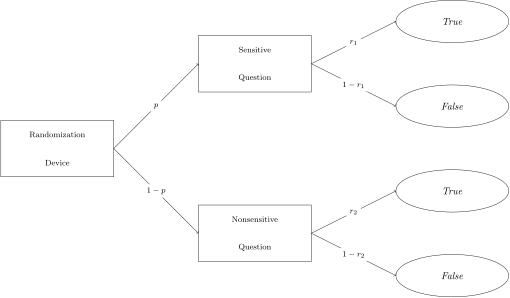

In [7]:
%%tikz -as=full-document
\documentclass[tikz]{standalone}
\begin{document}
\begin{tikzpicture}[scale = 1]
        \draw (0,-1) rectangle (4,1);
        \draw[->] (4,0) -- (7,3);
        \draw[->] (4,0) -- (7,-3);
        \draw (7,2) rectangle (11,4);
        \draw (7,-2) rectangle (11,-4);
        \draw[->] (11,3) -- (14,4.5);
        \draw[->] (11,3) -- (14,1.5);
        \draw[->] (11,-3) -- (14,-4.5);
        \draw[->] (11,-3) -- (14,-1.5);
        \draw (16, 4.5) ellipse (2cm and 0.75cm);
        \draw (16, 1.5) ellipse (2cm and 0.75cm);
        \draw (16, -1.5) ellipse (2cm and 0.75cm);
        \draw (16, -4.5) ellipse (2cm and 0.75cm);

        \node at (2,0.5) {\footnotesize Randomization};
        \node at (2,-0.5) {\footnotesize Device};
        \node[fill=white] at (5.5,1.5) {\footnotesize $p$};
        \node[fill=white] at (5.5,-1.5) {\footnotesize $1-p$};
        \node at (9,3.5) {\footnotesize Sensitive};
        \node at (9,2.5) {\footnotesize Question};
        \node at (9,-2.5) {\footnotesize Nonsensitive};
        \node at (9,-3.5) {\footnotesize Question};
        \node[fill=white] at (12.5,3.75) {\footnotesize $r_1$};
        \node[fill=white] at (12.5,2.25) {\footnotesize $1-r_1$};
        \node[fill=white] at (12.5,-3.75) {\footnotesize $1 -r_2$};
        \node[fill=white] at (12.5,-2.25) {\footnotesize $r_2$};
        \node at (16,4.5) {\textit{True}};
        \node at (16,1.5) {\textit{False}};
        \node at (16,-1.5) {\textit{True}};
        \node at (16,-4.5) {\textit{False}};
    \end{tikzpicture}
\end{document}

 - Using the diagram's notation, $t = pr_1 + (1 − p)r_2$.
 - Problem: Both $r_1$ and $r_2$ are unknown $\Rightarrow$ Two variables one
equation $\Rightarrow$ Impossible to determine $r_1$.
 - Solution:
    - Use a question whose distribution is known in advance, e.g., *Did you born in winter?*
    - Ask just the non-sensitive question in another survey
 - Recover the answer: $r_1 = \frac{t − (1 − p)r_2}{p}$.

## Unrelated questions - FGHA

One sample of the question is wasted to determine the non-sensitive parameter. There is a better way.

> ### Folsom, Greenberg, Horvitz, Abernathy (1973)
> Three questions to ask: one sensitive (Q1), two nonsensitive
(Q2 and Q3)
> Two types of interviews, both with two questions
> First question: Ask a random question from Q1 and Q2 (or
Q3 in the other type)
> Second question: Ask Q3 (or Q2 in the other type) directly.

Suppose we use a coin toss to determine the first question.

 ### Interview 1
 - HEAD: Did you cheat on your income taxes last year?
 - TAIL: Did you watch the football game last night?
 - Direct: Do you have any older living siblings?

 ### Interview 2
 - HEAD: Did you cheat on your income taxes last year?
 - TAIL: Do you have any older living siblings?
 - Direct: Did you watch the football game last night?

## Analysis

- $r_1, r_2, r_3$: ratio of *YES* answers to Q1, Q2, Q3 among population.
- $t_i^r, t_i^d$: ratio of *YES* answers to the randomized and direct question in the $i$-th typquestion in the interview.
- First interview: $t_1^r \approx pr_1 + (1-p)r_2$, and $t_1^d \approx r_3$.
- Second interview: $t_2^r \approx pr_1 + (1-p)r_3$, and $t_1^d \approx r_2$.
- We get two valus to $r_1$: $r_1' = \frac{t_1^r − t_2^d(1-p)}{p}$, $r_1'' = \frac{t_2^r − t_1^d(1-p)}{p}$
- To get the best estimate on $r_1$, we should take a weighted sum of $r_1'$ and $r_1''$:
$$ r_1 = wr_1' + (1 - w)r_1''.$$
$w$ is based on the variances of $r_1'$ and $r_1''$. If the same sample size is used for both questions, then $w = 0.5$ is a sufficient choice.


## Two-stage randomized response algorithm

> 1. Flip a coin.
> 2. If it heads, answers honestly.
> 3. If it tails, flip once again. If it heads, answer *yes*, otherwise answer *no*.

The algorithm provides DP with $\varepsilon = \log(3) = 1.09$.

## Deniability

 - Clearly, anyone who answers *yes* can state that it is due to the coin flip.
 - Firing squad execution: In Utah (the only state with this punishment), one of the five sharpshooters, at random, is given a rifle loaded with blanks. Each squad member can maintain that he had fired the blank.

## Usability

How can the survey conductor compute the number of individuals with the sensitive property?
 - If $p$ is the ratio of the sensitive attribute, $t$ is the ratio of yes answers, then $ t = 1/2\cdot p + 1/2\cdot 1/2$.
 - Therefore $ p = 2t - 1/2$.

In [8]:
n, p = 13545, 0.27
answers = generate_answers(n, p)
sum(answers)

3639

In [9]:
def randomized_response(attribute):
    if np.random.binomial(1, .5, 1) == 1:
        return attribute
    else:
        return np.random.binomial(1, .5, 1)[0]        

In [10]:
rand_answers = [randomized_response(x) for x in answers]
sum(rand_answers)

5155

In [11]:
real_ratio = 2 * sum(rand_answers) / n - 1/2
real_ratio

0.26116648209671467

## Mangat model

Idea:
 -  Different instructions for those who have the sensitive attribute.
 - If you have the sensitive attribute: answer honestly.
 - If not: randomize the answer.

> ## Mangat (1994)
> 1. The interviewer asks the sensitive question.
> 2. If A is true, say True.
> 3. Otherwise, use a random bit b. If b = 0, say *True*, if b = 1, say *False*.

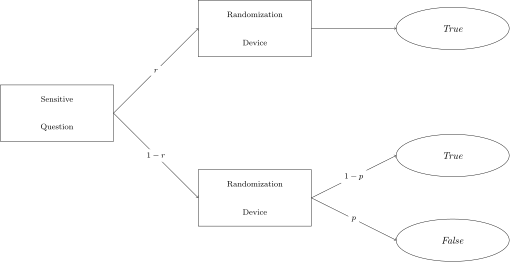

In [12]:
%%tikz
    \begin{tikzpicture}[scale = 1]
        \draw (0,-1) rectangle (4,1);
        \draw[->] (4,0) -- (7,3);
        \draw[->] (4,0) -- (7,-3);
        \draw (7,2) rectangle (11,4);
        \draw (7,-2) rectangle (11,-4);
        \draw[->] (11,3) -- (14,3);
        \draw[->] (11,-3) -- (14,-4.5);
        \draw[->] (11,-3) -- (14,-1.5);
        \draw (16, 3) ellipse (2cm and 0.75cm);
        \draw (16, -1.5) ellipse (2cm and 0.75cm);
        \draw (16, -4.5) ellipse (2cm and 0.75cm);

        \node at (2,0.5) {\footnotesize Sensitive};
        \node at (2,-0.5) {\footnotesize Question};
        \node[fill=white] at (5.5,1.5) {\footnotesize $r$};
        \node[fill=white] at (5.5,-1.5) {\footnotesize $1-r$};
        \node at (9,3.5) {\footnotesize Randomization};
        \node at (9,2.5) {\footnotesize Device};
        \node at (9,-2.5) {\footnotesize Randomization};
        \node at (9,-3.5) {\footnotesize Device};
        \node[fill=white] at (12.5,-3.75) {\footnotesize $p$};
        \node[fill=white] at (12.5,-2.25) {\footnotesize $1-p$};
        \node at (16,3) {\textit{True}};
        \node at (16,-1.5) {\textit{True}};
        \node at (16,-4.5) {\textit{False}};
    \end{tikzpicture}

## Estimate the real ratio

\begin{align*}
t &= r + (1 - r)p \\
r &=\frac{t - p}{1- p}
\end{align*}

## Forced alternative response

 - No need for a non-sensitive question.
 - The answer is fixed with some probability.

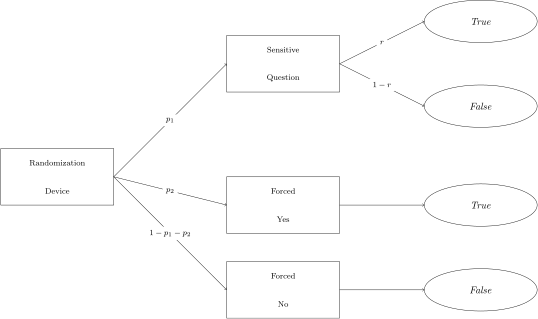

In [13]:
%%tikz
\begin{tikzpicture}[scale = 1]
        \draw (0,-1) rectangle (4,1);
        \draw[->] (4,0) -- (8,4);
        \draw[->] (4,0) -- (8,-4);
        \draw[->] (4,0) -- (8,-1);
        \draw (8,3) rectangle (12,5);
        \draw (8,-3) rectangle (12,-5);
        \draw (8,0) rectangle (12,-2);
        \draw[->] (12,4) -- (15,5.5);
        \draw[->] (12,4) -- (15,2.5);
        \draw[->] (12,-1) -- (15,-1);
        \draw[->] (12,-4) -- (15,-4);
        \draw (17, 5.5) ellipse (2cm and 0.75cm);
        \draw (17, 2.5) ellipse (2cm and 0.75cm);
        \draw (17, -1) ellipse (2cm and 0.75cm);
        \draw (17, -4) ellipse (2cm and 0.75cm);

        \node at (2,0.5) {\footnotesize Randomization};
        \node at (2,-0.5) {\footnotesize Device};
        \node[fill=white] at (6,2) {\footnotesize $p_1$};
        \node[fill=white] at (6,-0.5) {\footnotesize $p_2$};
        \node[fill=white] at (6,-2) {\footnotesize $1 - p_1 - p_2$};
        \node at (10,4.5) {\footnotesize Sensitive};
        \node at (10,3.5) {\footnotesize Question};
        \node at (10,-0.5) {\footnotesize Forced};
        \node at (10,-1.5) {\footnotesize Yes};
        \node at (10,-3.5) {\footnotesize Forced};
        \node at (10,-4.5) {\footnotesize No};
        \node[fill=white] at (13.5,4.75) {\footnotesize $r$};
        \node[fill=white] at (13.5,3.25) {\footnotesize $1-r$};
        %\node[fill=white] at (13.5,-4) {\footnotesize $1 -r_2$};
        %\node[fill=white] at (13.5,-1) {\footnotesize $r_2$};
        \node at (17,5.5) {\textit{True}};
        \node at (17,2.5) {\textit{False}};
        \node at (17,-1) {\textit{True}};
        \node at (17,-4) {\textit{False}};
    \end{tikzpicture} 

## Estimation

\begin{align*}
t = p_1r + p_2 \\
r = \frac{t-p_2}{p_1}
\end{align*}

## Experiment in 1982

Edgell, Himmelfarb, Duchan - considerable resistance among respondents to saying *YES* when forced to.
 - Random digits from microprocessor, 0 through 9:
   - 0, 1: say YES.
   - 8, 9: say NO.
   - Other: answer honestly.
 - 55 questions, 13 with fixed randomness.
 - 3 forced YES, however, not everybody complied.
   - 15% said NO to the tax cheating question.
   - 11% said NO to favor a nuclear power plant nearby.
   - 26% said NO to homosexual experience.
- 4 forced NO, almost everybody complied.

# Generalized Randomized Response (GRR)

 - Invented by Christofides.
 - More than two response options.
 - More protective of privacy.
 - More efficient than Warner.

 Setup:
 - Respondent $R_i$ gets a number $n_i \in \{0,L+1\}$: 
     - $n_i = 0$ if she/he has the sensitive attribute.
     - $n_i= L+1$ if she/he does not have the sensitive attribute.
 - $P = (p_1,\dots,p_L)$ is a probability distribution, $\sum p_i = 1$.
 
 Answer:
  - Respondent $R_i$ generates a random $r_i \in \{1,\dots,L\}$, such that $\Pr(r_i = j)= p_j$.
  - Answer: the distance of the number and a random: $d_i = \mid n_i - r_i \mid$.

### Example

 - Sensitive attribute: diabetes.
 - Let $L = 6$, $P=(0.26; 0.05; 0.1; 0.19; 0.02; 0.38)$.
 - Alice has diabetes. Alice's number is $6 + 1 = 7$.
 - Alice picks a random numer, from $\{1,\dots,6\}$. Suppose that it is 3.
 - Alice's response is $7 - 3 = 4$.


### Estimator:

 - $\theta$: prevalence of the sensitive parameter.
 - $\overline{d} = \sum  d_i /n$.
 - $E(P)$: expected value of prob. distribution $P$.
 - $$\theta = \frac{\overline{d} - E(P)}{L + 1- 2E(P)}.$$ 

# Non-Randomized Response (NRR)

Problem with randomized response:
 - Need a randomization method.
 - Might be complex/hard to follow the instructions.

## CWM (Crosswise model)

 Two questions:
  - sensitive with unknown prevalence $\pi_{CWM}$, e.g., "I have taken cocaine".
  - non-sensitive with known prevalence, e.g., "My mother was born in winter".
  
 Answer the two questions at the same time:
 - "Both statements are true, or none of the statements is true."
 - "Exactly one statement (irrespective of which one) is true."

### How to estimate $\pi_{CWM}$?

Let $t$ be the observed propoertion, $p$ be the probability for the second question: Then
$$ \pi_{CWM} = \frac{t + r-1}{2r-1}. $$

## TRM (Triangular model)

 Two questions:
  - sensitive with unknown prevalence $\pi_{TRM}$, e.g., "I have taken cocaine"
  - nonsensitive with known prevalence, e.g., "My mother was born in winter"
  
 Answer the two questions at the same time:
 - "None of the statements is true."
 - "At least one of the statements (irrespective of which one) is true."

### How to estimate $\pi_{TRM}$?

Let $t$ be the observed propoertion, $p$ be the probability for the second question: Then
$$ \pi_{TRM} = 1 -\frac{t}{1-r}. $$

## Comparison of CWM and TRM

Symmetry: both answer options can and must be chosen by both carriers and noncarriers of the sensitive attribute.
 - CWM has symmetry, while TRN does not.
 - Symmetric: No safe answers.
 - Asymmetric: Safe answer ("none of the statements is true") that precludes being a carrier of the sensitive attribute

Efficiency:
 - TRM is more efficient if both models are equally valid.
 - Respondents are less tempted to lie in CWM questions. 

## Comparison of NRRs with DQ

 - Two NRRs, CWN and TRM.
 - Studies show that both give better estimates than direct questioning.
 - Study on the prevalence of plagiarism with both CWM and TRM:
     - TRM is higher, but close to DQ.
     - CWM is much higher than DQ.

# Unary encoding

 - Goal: build a histogram with local DP
 - Google's RAPPOR system using this approach (with some modification)

## Unary encoding mechanism:

> 1. encode: encodes the response
> 2. perturb: perturbs the encoded response
> 3. aggregate: reconstructs final results from the perturbed responses

In [14]:
adult = pd.read_csv("data.csv")
adult.head(10)

,Name,First Name,Last Name,Sex,SSN,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
0,Jason Ortiz,Jason,Ortiz,Male,239-62-5065,12/24/65,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
1,Anna Brown,Anna,Brown,Female,860-48-3325,03/21/99,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
2,Kevin Anderson,Kevin,Anderson,Male,176-24-2913,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Patricia Clarke,Patricia,Clarke,Female,384-30-3488,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Robert Watson,Robert,Watson,Male,066-16-3817,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k
5,Joseph Carrillo,Joseph,Carrillo,Male,426-75-3893,12/23/88,12/23,35,60983,Masters degree,Never married,Designer/ multimedia,100k to 200k
6,Molly Rodriguez,Molly,Rodriguez,Female,610-28-1657,07/24/88,07/24,36,83909,Bachelors degree,Married,Theatre director,Under 25k
7,Kenneth Smith,Kenneth,Smith,Male,521-01-8305,04/14/02,04/14,22,90525,High school/GED,Never married,Oceanographer,50k to 100k
8,Andrea Hale,Andrea,Hale,Female,586-74-2173,10/27/97,10/27,26,16072,Associate degree,Never married,Solicitor,50k to 100k
9,Tamara Reyes,Tamara,Reyes,Female,034-40-4605,11/04/93,11/04,30,17275,High school/GED,Married,Adult nurse,25k to 50k


We want to determine how many participants achieved different education grades.

In [15]:
domain = adult['Education'].dropna().unique()
domain

array(['Bachelors degree', 'No degree', 'High school/GED',
       'Masters degree', 'Associate degree', 'Some college', 'Doctorate',
       'Professional degree'], dtype=object)

We have 8 types of grades.

## Encoding:

 - Each response is encoded as a binary vector of 8  bits, with all positions 0 except the one corresponding to the occupation of the respondent.
 - E.g., for Jason Ortiz, it is [1,0,0,0,0,0,0,0], and for Andrea Hale, it is [0,0,0,0,1,0,0,0].

In [16]:
def encode(response):
    return [1 if d == response else 0 for d in domain]

encode('Doctorate')

[0, 0, 0, 0, 0, 0, 1, 0]

## Perturb

- Generate a random bit. $\Pr[b = 1] = p$, $\Pr[b = 0] = 1 - p$.
- The privacy parameter $\varepsilon$ is depending on $p$.
- $\varepsilon = 2\log\left( \frac{p}{1-p} \right)$.

In [17]:
def perturb(encoded_response):
    return [perturb_bit(b) for b in encoded_response]

def perturb_bit(bit):
    p = .75

    sample = np.random.random()
    if bit == 1:
        return np.random.binomial(1, p, 1)[0]
    else:
        return np.random.binomial(1, 1 - p, 1)[0]

perturb(encode('Doctorate'))

[0, 1, 1, 0, 0, 1, 1, 0]

In [18]:
def unary_epsilon(p):
    return 2 * np.log(p / (1 - p))

unary_epsilon(.75)

2.1972245773362196

## Aggregation

- If no perturbation, add up the response vectors to get the final result.

In [19]:
counts = np.sum([encode(r) for r in adult['Education']], axis=0)
list(zip(domain, counts))

[('Bachelors degree', 4337),
 ('No degree', 2010),
 ('High school/GED', 5793),
 ('Masters degree', 1915),
 ('Associate degree', 2058),
 ('Some college', 3251),
 ('Doctorate', 381),
 ('Professional degree', 255)]

 - The perturbation, however, changes the outcome. 

In [20]:
counts = np.sum([perturb(encode(r)) for r in adult['Education']], axis=0)
list(zip(domain, counts))

[('Bachelors degree', 7261),
 ('No degree', 5982),
 ('High school/GED', 7949),
 ('Masters degree', 5964),
 ('Associate degree', 6022),
 ('Some college', 6769),
 ('Doctorate', 5120),
 ('Professional degree', 5057)]

## How to estimate the real number of individuals with the degrees?

 - $p$: perturbation probability
 - $r$: real answer
 - $n$: number of individuals
 - $t$: perturbared answer
 - $r \approx t - \frac{t - n(1-p)}{2p- 1} $, because $ t \approx rp + (n - r)(1 - p) $

In [21]:
def aggregate(responses):
    p = .75
    
    sums = np.sum(responses, axis=0)
    n = len(responses)
    
    return [(r - n*(1-p)) / (2*p-1) for r in sums]  

In [22]:
responses = [perturb(encode(r)) for r in adult['Education']]
counts = aggregate(responses)
list(zip(domain, counts))

[('Bachelors degree', 4338.0),
 ('No degree', 2094.0),
 ('High school/GED', 5828.0),
 ('Masters degree', 1948.0),
 ('Associate degree', 2034.0),
 ('Some college', 3294.0),
 ('Doctorate', 470.0),
 ('Professional degree', 202.0)]

## Analysis

- The results are accurate enough to obtain a rough ordering of the domain elements.
- But orders of magnitude less accurate than the Laplace mechanism in the central model.

# Some final note on differential privacy

## How to chose $\varepsilon$ ?

 - Privacy and accuracy highly depend on $\varepsilon$.
 - Smaller $\varepsilon$ means more privacy, but less accuracy.
 - Higher $\varepsilon$ means more accuracy, but less privacy.

## How to chose $\varepsilon$ ?

 There is no consensus; it depends on the query (privacy mechanism, number of individuals, and how sensitive the information is).
 - $\varepsilon \le 0.01$: Offers extreme privacy, often used in contexts where privacy is of the utmost importance, but this may result in significant loss of utility.
 - $\varepsilon \in [0.01,0.1]$: Common in privacy-sensitive applications (e.g., health data) where privacy concerns are high, but utility is still essential.
 - $\varepsilon \in [0.1,1]$: This range is often considered a good balance between privacy and utility in many practical applications.
 - $\varepsilon \in [1,10]$: More utility-oriented settings, such as recommendation systems or advertising, where privacy is necessary but not critical.

## How to chose $\varepsilon$ ?

Real-life examples:
 - Apple reportedly uses $\varepsilon = 2$ for some of its differential privacy applications.
 - Google uses values in the range of $\varepsilon = 0.1$ to $\varepsilon = 8$ depending on the specific service.

## What is DP not usable for

The consequence of DP is hiding an individual's presence in the dataset.
 - Study outliers.
 - Analyzing small datasets

DP can influence the treatment of specific individuals, whether their data were in the database or not. E.g., suppose DP shows a correlation between a deasease and higher death rate. In that case, individuals with the disease may have worse insurance rates.